# Cyber Trend Forecasting - VisionTS++ Pipeline (Smoothed, alpha=0.01)

**Vignette Description:**
This notebook acts as the Pipeline Dashboard for the project. It handles the end-to-end workflow:
1.  **Setup:** Automatically detects if running on Google Colab or the NATO Local Server.
2.  **Zero-Shot Forecast:** Executes `Evaluate_VisionPP.py` - the pretrained VisionTS++ model with chunked rendering.
3.  **Evaluation:** Generates metrics and predictions for all 1,231 dataset columns.
4.  **Visualisation:** Displays the smoothed forecasts and the Gap Analysis inline.
5.  **Multi-Model:** Re-runs the evaluation and all visualisations with the per-series multi-model combined forecast (the headline result).

**Smoothed-output variant (alpha=0.01).** This notebook is a copy of `VisionPP_v2_2_Vignette.ipynb` with exponential smoothing applied to the plotted series, using the smoothing function from
`Data_Pipeline/Visualise_Comparison.py` (the same convention as the B-MTGNN outlook figures).

## Universal Setup

This cell handles the setup logic: mounting Google Drive if on Colab, or using relative paths if on the GPU server

In [1]:
import os
import sys
import contextlib

# --- CONFIGURATION ---
# If on Colab, ensure you have set the Secret 'project_path' to your Project Root
# e.g., /content/drive/MyDrive/NATO_Project_Root

try:
    # 1. CHECK ENVIRONMENT: Try to import Colab-specific modules
    from google.colab import drive, userdata
    IS_COLAB = True
    print("--- Detected Environment: GOOGLE COLAB ---")
except ImportError:
    IS_COLAB = False
    print("--- Detected Environment: LOCAL SERVER (NATO/BBK) ---")

# 2. PATH SETUP
if IS_COLAB:
    # --- COLAB SETUP ---
    try:
        drive.mount('/content/drive')

        # Get the PARENT ROOT from Secrets
        PROJECT_ROOT = userdata.get('project_path')
        if not PROJECT_ROOT:
            raise ValueError("Secret 'project_path' is missing.")

    except Exception as e:
        print(f"COLAB SETUP ERROR: {e}")
        # Stop execution if we can't find the files
        raise e
else:
    # --- LOCAL SETUP ---
    # We assume this notebook is in 'Notebooks/', so Root is one level up
    # os.getcwd() returns /.../Project_Root/Notebooks
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 3. CONFIGURE WORKING DIRECTORY
# We need to run scripts from inside 'Transformer_Pipeline'
PIPELINE_DIR = os.path.join(PROJECT_ROOT, 'Transformer_Pipeline')

if not os.path.exists(PIPELINE_DIR):
    raise FileNotFoundError(f"Could not find pipeline folder at: {PIPELINE_DIR}")

# Change CWD to the pipeline folder so scripts can find config/data
os.chdir(PIPELINE_DIR)
print(f"SUCCESS: Working Directory set to: {os.getcwd()}")

# 4. ADD PROJECT ROOT TO SYS.PATH
# This allows us to import 'Notebooks.colab_utils' if needed
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print(f"Added Project Root to sys.path: {PROJECT_ROOT}")

# 5. INSTALL DEPENDENCIES (COLAB ONLY)
if IS_COLAB:
    print("\n--- Installing Dependencies (Colab Only) ---")
    # We import the helper script from the sibling folder
    try:
        from Notebooks import Colab_Utils
        # This creates a temporary black hole for the print statements
        with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f):
            Colab_Utils.setup_environment(PIPELINE_DIR)
        print("Dependencies verified successfully!")
    except ImportError:
        print("WARNING: Could not import Notebooks.colab_utils. Skipping auto-install.")

# On Apple Silicon, enable the fallback for unsupported MPS ops:
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

--- Detected Environment: LOCAL SERVER (NATO/BBK) ---
SUCCESS: Working Directory set to: Transformer_Pipeline
Added Project Root to sys.path: .


'1'

### Imports

In [2]:
from pathlib import Path

from Transformer_Pipeline.Visualise_VisionPP_Results import (
    visualise_evaluation_metrics,
    load_visualisation_data,
    perform_broad_analysis,
    plot_validation_forecasts,
    generate_gap_analysis_tables,
    plot_continuous_trends
)

DATASET = "v2_2_full"

import numpy as np

SMOOTHING_ALPHA = 0.01

# Copied verbatim from Data_Pipeline/Visualise_Comparison.py so these plots
# use the same smoothing convention as the B-MTGNN outlook figures.
def exponential_smoothing(series, alpha=0.1):
    """
    Applies exponential smoothing to reduce noise, explicitly clamping at 0
    to prevent illogical negative dips in the graph.
    """
    if len(series) == 0:
        return series

    result = [max(0, series[0])]
    for n in range(1, len(series)):
        val = alpha * series[n] + (1 - alpha) * result[n - 1]
        result.append(max(0, val))

    return np.array(result)


def smooth_vis_data(data, alpha=None):
    """Apply plot-level smoothing to every series used by the visualisations.

    Visualisation only: the evaluation metrics elsewhere in this notebook are
    computed on the unsmoothed forecasts. Note the gap-analysis tables are
    derived from these smoothed series, matching the plots.
    """
    if alpha is None:
        alpha = SMOOTHING_ALPHA
    if not data:
        return data
    for key in ("history_data", "preds_window", "trues_forecast_period"):
        arr = np.asarray(data[key], dtype=float)
        data[key] = np.column_stack(
            [exponential_smoothing(arr[:, j], alpha) for j in range(arr.shape[1])]
        )
    return data


## Optional: Re-Generate Vision Data

Run this cell if you want to rebuild the preprocessed windows from the raw CSV data. If you have already processed the data, you can skip this step.

In [3]:
# Runs the preprocessing scripts to generate the VisionTS++ artifacts
# We use !python to run these as clean subprocesses

# We are currently in the 'Transformer_Pipeline' directory.
# The scripts will resolve paths automatically.

!{sys.executable} -W ignore -m Preprocessing.Cyber_Trend_to_Image \
    --dataset v2_2_full --window-first \
    --feature-names-file Preprocessing/v2_2_all_features_1231.txt 2>/dev/null
!{sys.executable} -W ignore -m Preprocessing.Cyber_Trend_to_Image_PP \
    --dataset v2_2_full --force 2>/dev/null

Vision Pipeline Preprocessing

--- Configuration ---
Dataset:                 v2_2_full
Raw data file:           Transformer_Pipeline/Preprocessing/../../Data_Preparation/Cyber_Trend_Forecasting_All_v2_2_sarimax.csv
Context Window (input):  36 months
Forecast Horizon (pred): 36 months
Splits: Train=43%, Val=30%, Test=27%
Windowing Strategy: Window-First (more samples)
Dimensionality Reduction: Pinned (names from Preprocessing/v2_2_all_features_1231.txt)
Output Directory: Transformer_Pipeline/Preprocessing/../../Processed_Data/vision/v2_2_full

--- Step 0: Loading Raw Data ---
DEBUG: Attempting to load file from: Transformer_Pipeline/Preprocessing/../../Data_Preparation/Cyber_Trend_Forecasting_All_v2_2_sarimax.csv
Loading raw data (dataset='v2_2_full')...


Parsing dates from column 'Date' with format '%b-%y'...
Data loaded and sorted successfully.
 - Time Range: 2011-07-01 to 2025-12-01
 - Total Months: 174
 - DataFrame Shape: (174, 1231)

--- Applying Double Exponential Smoothing (alpha=0.1, beta=0.1) ---


Smoothed 1231/1231 columns.

Using WINDOW-FIRST approach (maximum training samples)

--- Pinned Feature Selection (from Preprocessing/v2_2_all_features_1231.txt) ---


Selected 1231 pinned features (variance/correlation/PCA filters and vignette forcing bypassed)

--- Creating Sliding Windows on Full Dataset ---

--- Step 2: Creating Sliding Windows ---
Generated shapes: X=(103, 36, 1231), y=(103, 36, 1231)
  X: (samples=103, context_len=36, nvars=1231)
  y: (samples=103, pred_len=36, nvars=1231)
Total windows created: 103

--- Splitting Windowed Data ---
Train samples: 44
Val samples:   31
Test samples:  28

--- Step 1: Computing Reference Scaler (NOT applied to data) ---
Reference scaler saved to Transformer_Pipeline/Preprocessing/../../Processed_Data/vision/v2_2_full/scaler.pkl
NOTE: VisionTS handles normalization internally - scaler saved for reference only.

Total samples: 103 (train=44, val=31, test=28)

--- Step 4: Saving Processed Data ---


Saved train.npz: X=(44, 36, 1231), y=(44, 36, 1231)
Saved val.npz:   X=(31, 36, 1231), y=(31, 36, 1231)
Saved test.npz:  X=(28, 36, 1231), y=(28, 36, 1231)


Saved feature_names.npy: 1231 features
Saved metadata.pkl
Saving complete.

Vision Pipeline Preprocessing Complete

Output files saved to: Transformer_Pipeline/Preprocessing/../../Processed_Data/vision/v2_2_full
Files created:
  - train.npz, val.npz, test.npz (windowed data)
  - scaler.pkl (reference scaler - NOT applied to data)
  - feature_names.npy (selected/original column names)
  - metadata.pkl (preprocessing parameters)


Dataset: v2_2_full
  Source: Processed_Data/vision/v2_2_full
  Dest:   Processed_Data/visionpp/v2_2_full
VisionTS++ Data Preparation

Copying data from existing vision preprocessing: Processed_Data/vision/v2_2_full
  Copied: train.npz
  Copied: val.npz
  Copied: test.npz
  Copied: metadata.pkl
  Copied: feature_names.npy
  Copied: scaler.pkl
  Copied: feature_selection.pkl

Data prepared at: Processed_Data/visionpp/v2_2_full
Ready to train VisionTS++!


## Step 1: Zero-Shot Forecast (VisionTS++)

We now execute the forecasting script.
- **Input:** `Cyber_Trend_VisionPP_Config.py` (per-dataset defaults: chunk_size=6, periodicity=1, num_patch_input=7)
- **Output:** `visionpp_predictions.npy` (forecasts for all 1,231 columns)

The model is the pretrained VisionTS++ (MAE-base) with inference-time chunked rendering. The "WARNING: No checkpoint found" message is EXPECTED - it confirms the model runs zero-shot from pretrained weights. The Appendix demonstrates overfit during training.

*Note: On first run the pretrained checkpoint (~450 MB) is downloaded from HuggingFace. Inference takes ~5 minutes on GPU.*

In [4]:
print("--- Step 1: Zero-Shot Forecast (VisionTS++) ---")
%run Evaluate_VisionPP.py --dataset v2_2_full

--- Step 1: Zero-Shot Forecast (VisionTS++) ---


--- Loading Test Data from Processed_Data/visionpp/v2_2_full ---
Initializing VisionTS dataset for split: test from Processed_Data/visionpp/v2_2_full
Loading windowed data from Processed_Data/visionpp/v2_2_full/test.npz...
Loaded 28 samples for test.
  X shape: (28, 36, 1231) (samples, context_len, nvars)
  y shape: (28, 36, 1231) (samples, pred_len, nvars)
Test samples: 28
Dimensions: context=36, pred=36, features=1231
Using device: mps

--- Loading VisionTS++ Model ---
Init VisionTS++ wrapper:
  - Architecture: mae_base
  - Fine-tune type: ln
  - Context length: 36
  - Prediction length: 36
  - Number of features: 1231
  - Quantile prediction: True
  - Color encoding: True
           Consider using feature selection to reduce dimensions


Load Processed_Data/visionpp/v2_2_full/ckpt/visiontspp_model.ckpt
  - Periodicity: 1
  - Norm const: 0.4
  - Align const: 0.4
  - Chunk size: 6
VisionTS++ initialized. Parameters: 55,808 trainable / 115,059,712 total
Running with pretrained weights only.

--- Running Inference ---


Predictions shape: (28, 36, 1231)
Ground truth shape: (28, 36, 1231)

--- Calculating Metrics per Horizon ---

Evaluation Results
  Horizon      RSE      RAE      MAE     CORR
 3 Months 0.074843 0.047060 0.616217 0.997234
 6 Months 0.125631 0.074316 0.974805 0.992212
12 Months 0.206813 0.124511 1.650318 0.978602
24 Months 0.304286 0.197220 2.740597 0.952640
  Overall 0.334008 0.230537 3.397539 0.944414

Saved results table to Transformer_Pipeline/Results/v2_2_full/visionpp_evaluation_results.csv

--- Saving Raw Predictions ---
Saved prediction arrays to Transformer_Pipeline/Results/v2_2_full/
Saved prediction arrays to Processed_Data/visionpp/v2_2_full/

--- Data Preprocessing Summary ---
Original features: 1231


## Step 2: Evaluation & Metrics

The forecast step above already ran the model against the Test Set.
* It calculates **RSE, RAE, MAE, and CORR** across horizons (3, 6, 12, 24 months).
* It saves the raw predictions to `.npy` files for visualisation.
* It exports the results to a CSV file.

--- Step 2: Evaluation Metrics (zero-shot) ---

--- PUBLICATION PREVIEW: Evaluation Metrics ---

--- Generating Evaluation Metrics Table ---


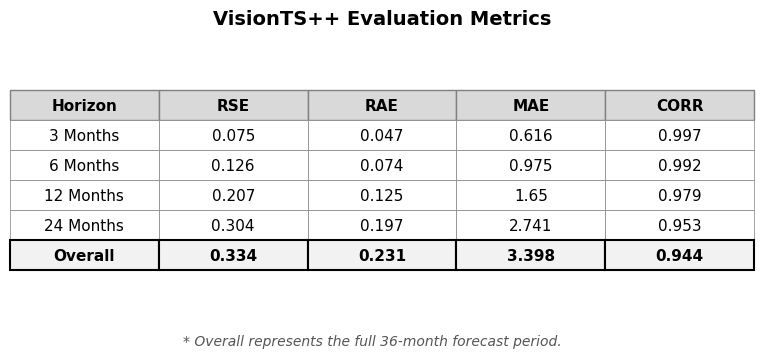

Saved: Vision_Eval_Table.png (and archived to archive/)


In [5]:
print("--- Step 2: Evaluation Metrics (zero-shot) ---")

print("\n--- PUBLICATION PREVIEW: Evaluation Metrics ---")
visualise_evaluation_metrics(dataset=DATASET)

## Step 3: Visualise Results

This section executes the visualisation pipeline to interpret the VisionTS++ model's output. 

### Setup & Data Loading

In [ ]:
current_dir = Path.cwd()
if str(current_dir.parent) not in sys.path: sys.path.append(str(current_dir.parent))

# Load data into vis_data
vis_data = load_visualisation_data(dataset=DATASET)
# Plot-level smoothing (visualisation only. metrics stay unsmoothed)
vis_data = smooth_vis_data(vis_data)

if vis_data: print("Data Loaded Successfully.")
else: print("Failed to load data.")

--- Loading Visualisation Data ---
Loading Full History from: Data_Preparation/Cyber_Trend_Forecasting_All_v2_2_sarimax.csv
Data Loaded Successfully.


### Broad Analysis: Global Trends
This cell generates two high-level aggregate plots to assess the overall state of the cybersecurity landscape:

* **Global Forecast Accuracy:** Compares the **Global Average Ground Truth** (Black) against the **Global Average Prediction** (Blue) across all nodes. This provides a macroscopic view of the model's reliability.
* **Global Gap Analysis (Threat Intensity vs Mitigation Maturity):** Plots the **Average Threat Intensity** (Red) against the **Average Mitigation Maturity** (Green) for the entire dataset.
    * **Risk Gap (Red Shading):** Indicates periods where threats generally outpace available solutions.
    * **Safety Margin (Green Shading):** Indicates periods where defense maturity exceeds threat intensity.


--- FORECAST ACCURACY: Ground Truth vs Prediction ---


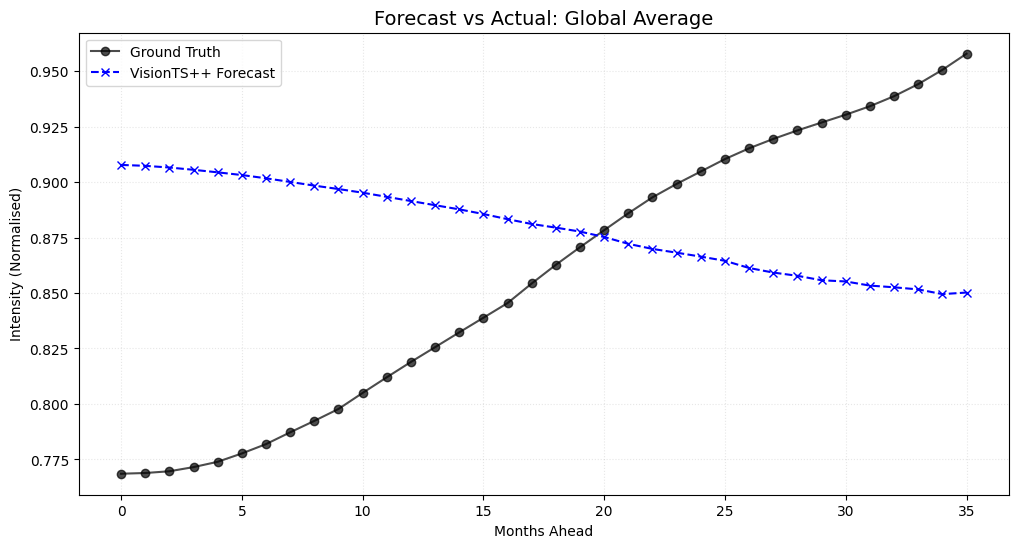

Saved: Global_Forecast_Accuracy.png (and archived to archive/)

--- GAP ANALYSIS: Threat vs Mitigation ---


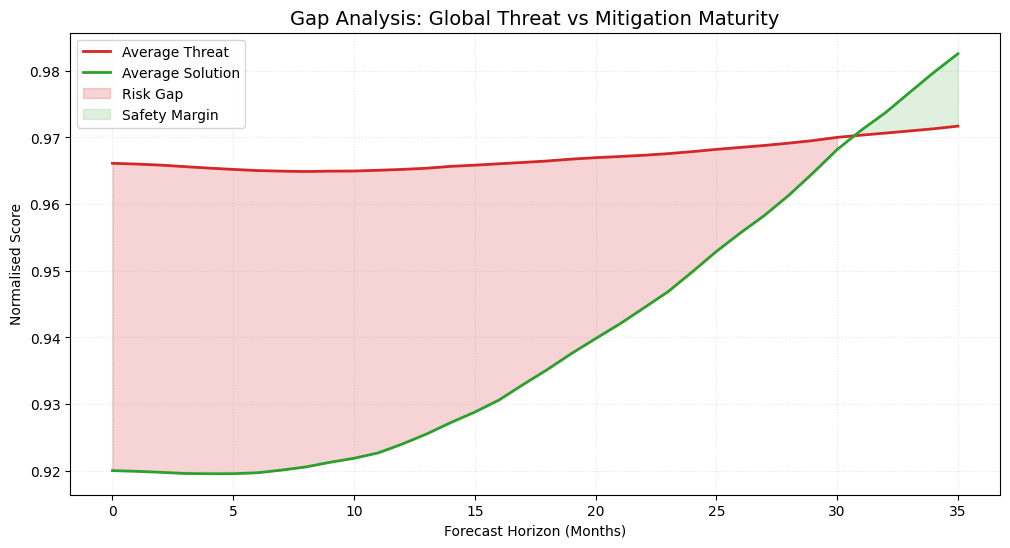

Saved: Global_Gap_Analysis.png (and archived to archive/)


In [7]:
if vis_data:
    perform_broad_analysis(vis_data)

### Forecast Accuracy (Ground Truth vs Prediction)
This cell generates the validation plots corresponding to **Figure 3** in the paper. It visualises the model's performance on specific, high-priority validation nodes (e.g., *Password Attack*, *NLP/LLM*, *Data Backups*).

* **Visuals:** It plots the **Actual Ground Truth** (Blue Line) versus the **VisionTS++ Forecast** (Purple Dashed Line) over the test period.
* **Confidence:** The shaded region represents the **95% Confidence Interval** of the prediction.


--- Figure 3: Forecast Accuracy (Ground Truth vs Prediction) ---


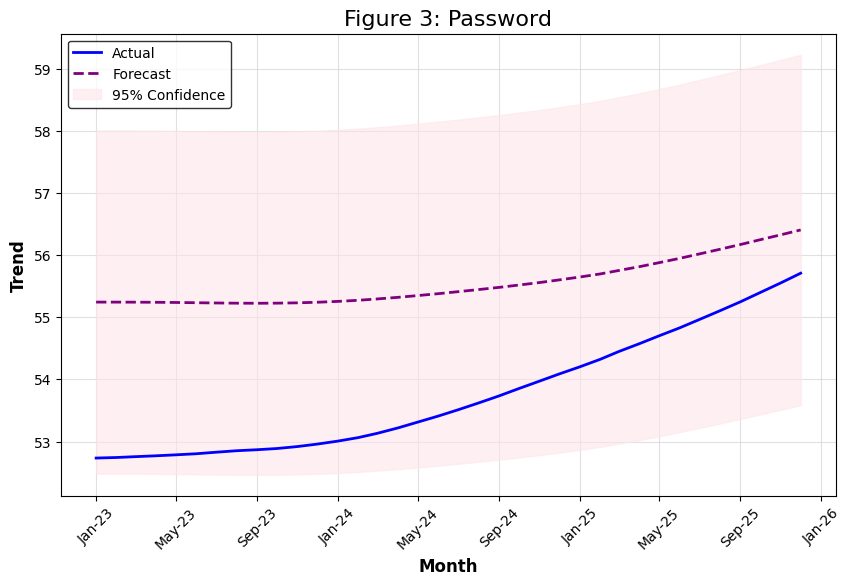

Saved: Fig3_Password.png (and archived to archive/)


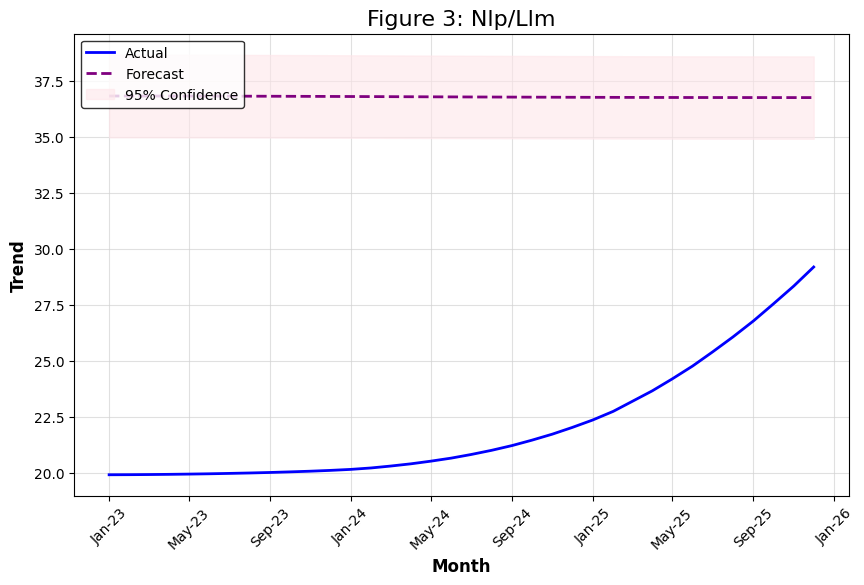

Saved: Fig3_Nlp_Llm.png (and archived to archive/)


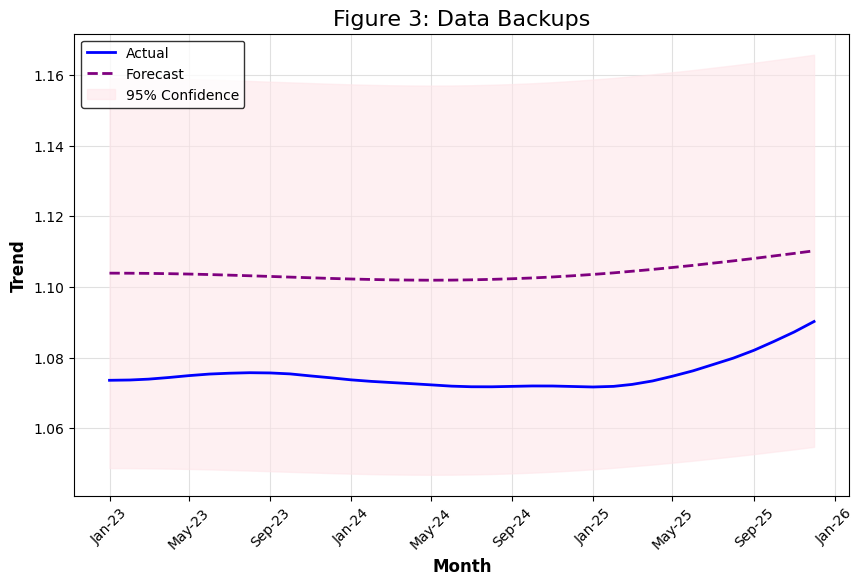

Saved: Fig3_Data_Backups.png (and archived to archive/)


In [8]:
if vis_data:
    plot_validation_forecasts(vis_data)

### Gap Analysis Tables (Tables 5 & 6)
This cell performs a quantitative analysis of the "Risk Gap" defined in the paper. It calculates the numerical difference between Threat Intensity and Solution Maturity for every pair in the knowledge graph over the forecast window (2023-2025).

* **Table 5 (Widening Gaps):** Identifies pairs where the gap is increasing year-over-year (Strictly Widening) or is larger at the end of the period than the start (Overall Widening). These represent emerging risks.
* **Table 6 (Narrowing Gaps):** Identifies pairs where the gap is decreasing, indicating "Success Stories" where mitigation strategies are effectively catching up to the threat.


--- GAP TABLES: Widening & Narrowing ---


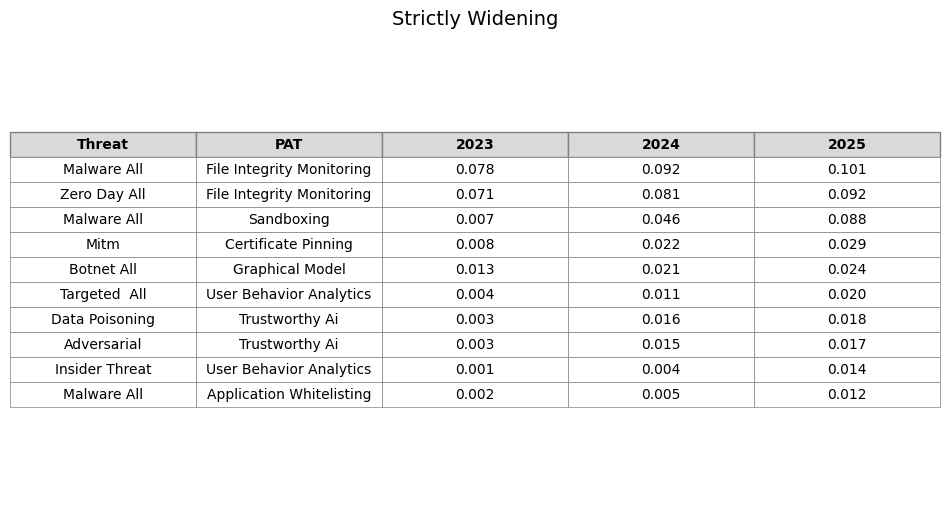

Saved: Strictly_Widening.png (and archived to archive/)

--- Table 5a: Strictly Widening Gaps (Top 5) ---
      Threat                       PAT  2023  2024  2025
 Malware All File Integrity Monitoring 0.078 0.092 0.101
Zero Day All File Integrity Monitoring 0.071 0.081 0.092
 Malware All                Sandboxing 0.007 0.046 0.088
        Mitm       Certificate Pinning 0.008 0.022 0.029
  Botnet All           Graphical Model 0.013 0.021 0.024


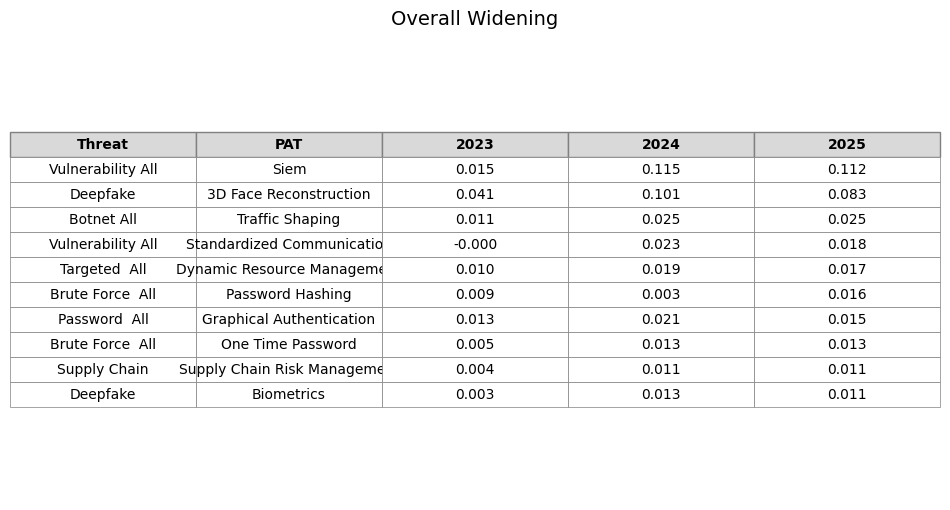

Saved: Overall_Widening.png (and archived to archive/)

--- Table 5b: Overall Widening Gaps (Top 5) ---
           Threat                         PAT   2023  2024  2025
Vulnerability All                        Siem  0.015 0.115 0.112
         Deepfake      3D Face Reconstruction  0.041 0.101 0.083
       Botnet All             Traffic Shaping  0.011 0.025 0.025
Vulnerability All  Standardized Communication -0.000 0.023 0.018
    Targeted  All Dynamic Resource Management  0.010 0.019 0.017


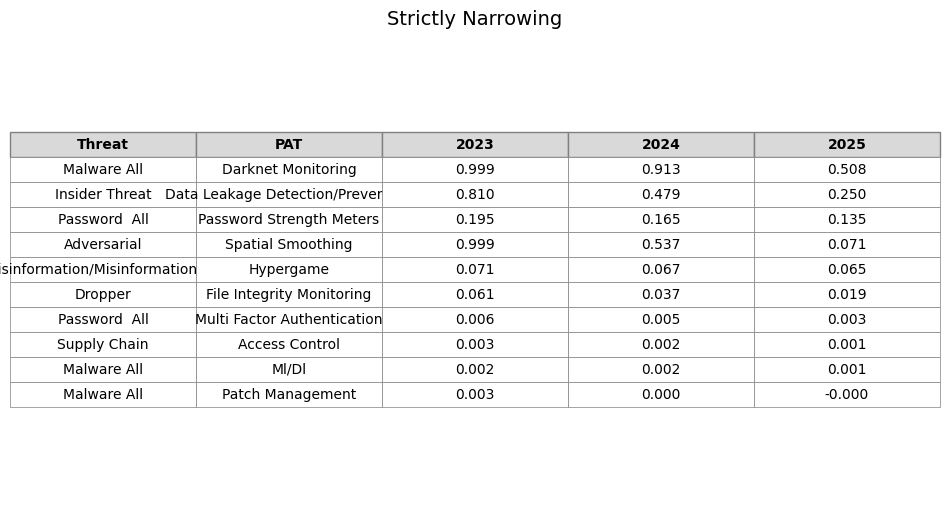

Saved: Strictly_Narrowing.png (and archived to archive/)

--- Table 6a: Strictly Narrowing Gaps (Top 5) ---
                           Threat                               PAT  2023  2024  2025
                      Malware All                Darknet Monitoring 0.999 0.913 0.508
                   Insider Threat Data Leakage Detection/Prevention 0.810 0.479 0.250
                    Password  All          Password Strength Meters 0.195 0.165 0.135
                      Adversarial                 Spatial Smoothing 0.999 0.537 0.071
Disinformation/Misinformation All                         Hypergame 0.071 0.067 0.065


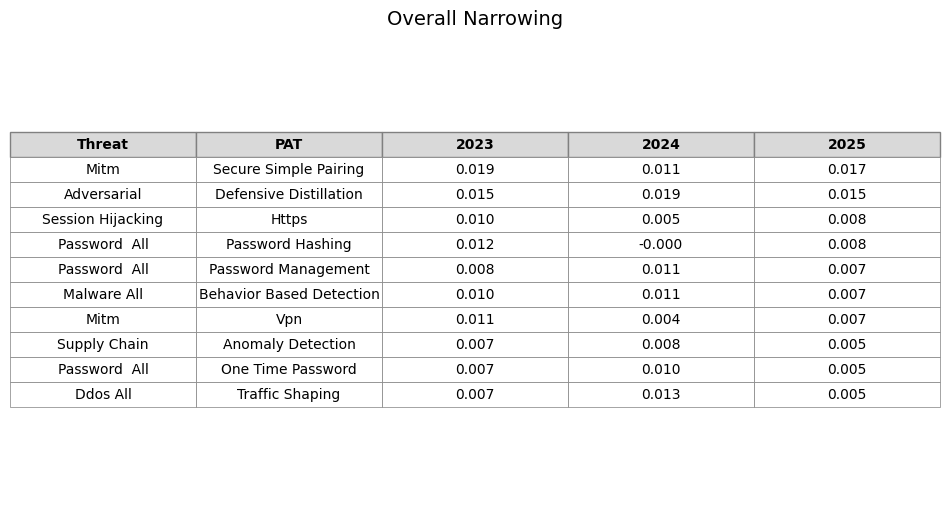

Saved: Overall_Narrowing.png (and archived to archive/)

--- Table 6b: Overall Narrowing Gaps (Top 5) ---
           Threat                    PAT  2023   2024  2025
             Mitm  Secure Simple Pairing 0.019  0.011 0.017
      Adversarial Defensive Distillation 0.015  0.019 0.015
Session Hijacking                  Https 0.010  0.005 0.008
    Password  All       Password Hashing 0.012 -0.000 0.008
    Password  All    Password Management 0.008  0.011 0.007


In [9]:
if vis_data:
  generate_gap_analysis_tables(vis_data)

### Continuous Trends (2011-2028)
This cell generates **Figure 4**, which stitches the historical data (2011-2022) with the model's forecast (2023-2028) to visualise the continuous 14-year evolution of major threat vectors (e.g., *Malware*, *Ransomware*).

* **The Trend:** The Black Line represents the continuous trend from the past into the future.
* **The Forecast:** The future period (2023-2025) includes 95% confidence shading.
* **Mitigation Context:** Where applicable, relevant solution trends (Green/Blue lines) are plotted alongside the threat to visualise the long-term interaction between attack vectors and defense mechanisms.


--- PAPER FIG 4: Continuous Trends ---


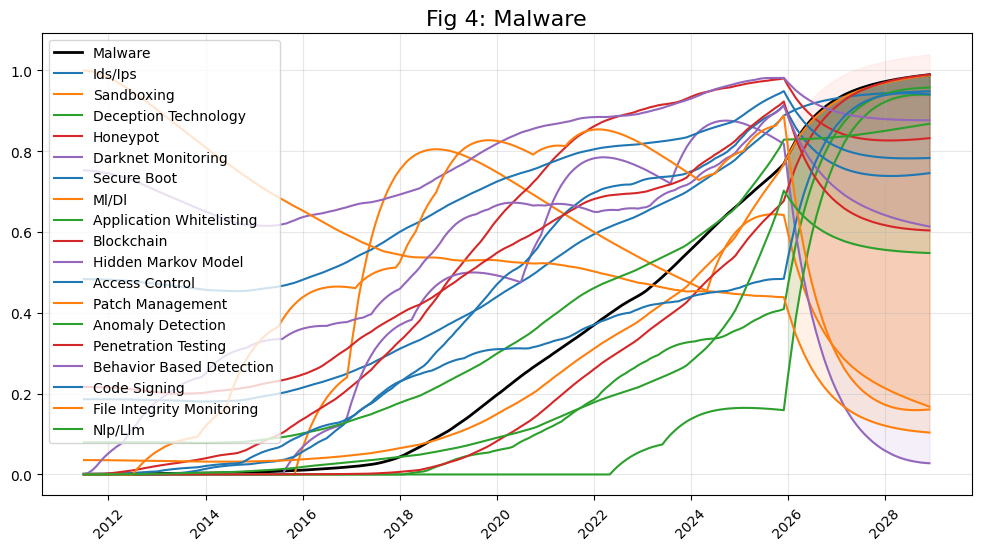

Saved: Fig4_Malware.png (and archived to archive/)


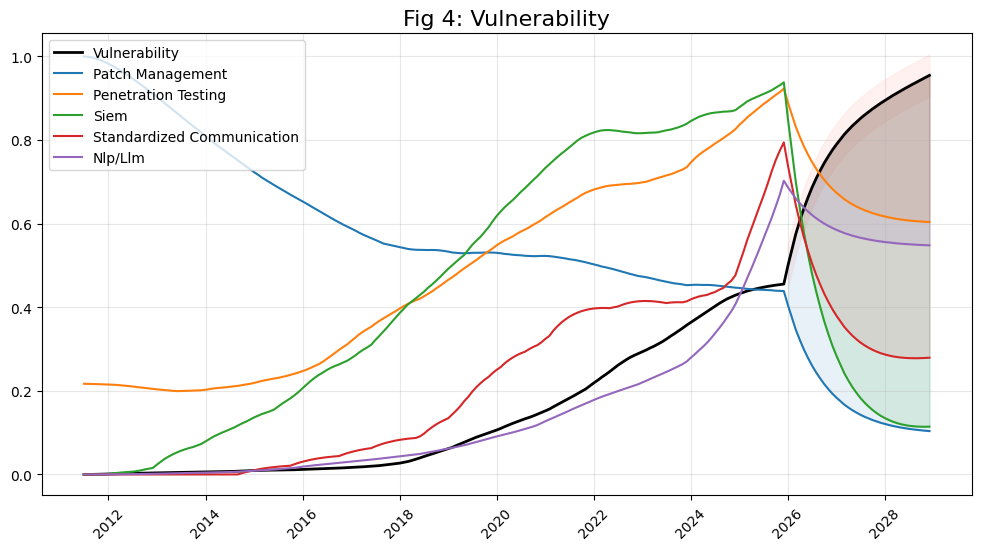

Saved: Fig4_Vulnerability.png (and archived to archive/)


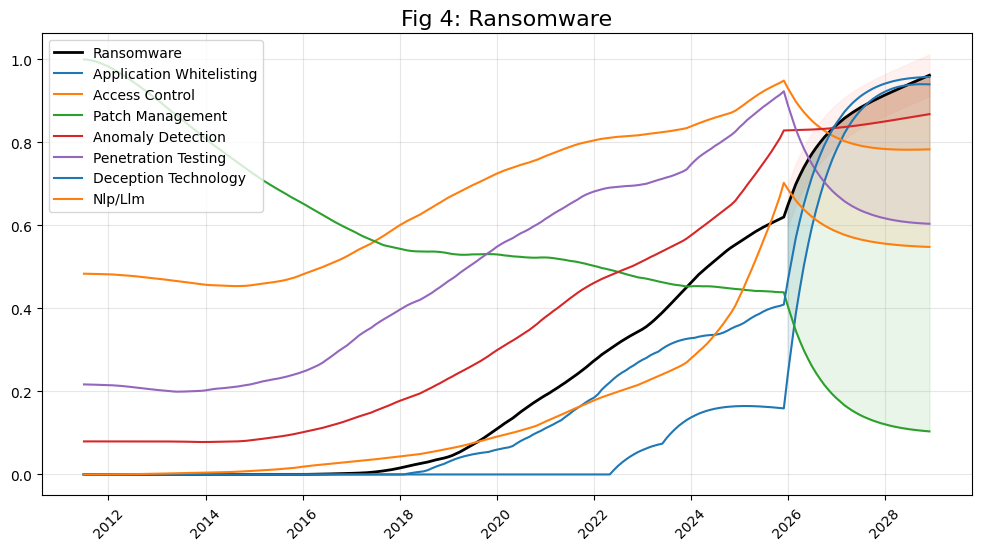

Saved: Fig4_Ransomware.png (and archived to archive/)


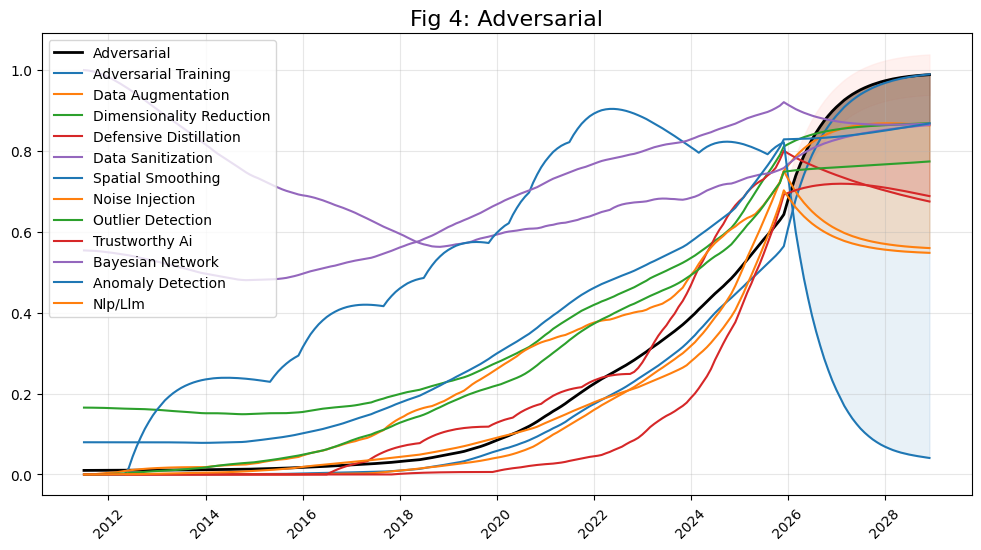

Saved: Fig4_Adversarial.png (and archived to archive/)


In [10]:
if vis_data:
    plot_continuous_trends(vis_data)

## Multi-Model: Re-Run Everything with the Headline Combined Forecast

The multi-model forecast is the best result. It keeps the zero-shot VisionTS++ forecast everywhere it wins and reassigns individual (feature, horizon-band) cells of the 159-feature benchmark subset to a better causal candidate where the validation split says so - a seasonal(periodicity-12) rendering, per-series SARIMA, or SARIMAX with 12-month-LAGGED Reddit war/conflict signals.

The cells below run the multi-model selection, combine its output into the prediction arrays, and then re-run   the evaluation metrics and all four visualisations on the multi-model forecasts. A pure zero-shot backup is saved alongside.

In [11]:
MULTI_MODEL_DIR = os.path.join('Results', 'v2_2_full', 'experiments', 'multi_model')

print("--- Multi-Model: candidate forecasts ---")
!{sys.executable} {os.path.join(MULTI_MODEL_DIR, 'multi_model_phase1.py')}

print("\n--- Multi-Model: SARIMA / SARIMAX-lagged-Reddit candidates ---")
!{sys.executable} {os.path.join(MULTI_MODEL_DIR, 'multi_model_phase2.py')}

print("\n--- Multi-Model: selection (val only) + single test evaluation ---")
!{sys.executable} {os.path.join(MULTI_MODEL_DIR, 'multi_model_phase3.py')}

--- Multi-Model: candidate forecasts ---


full features: 1231, benchmark slice: 159
stitch max deviation: 0.000e+00
device: mps
Init VisionTS++ wrapper:
  - Architecture: mae_base
  - Fine-tune type: ln
  - Context length: 36
  - Prediction length: 36
  - Number of features: 1231
  - Quantile prediction: True
  - Color encoding: True
           Consider using feature selection to reduce dimensions


Load Processed_Data/visionpp/v2_2_full/ckpt/visiontspp_model.ckpt


  - Periodicity: 1
  - Norm const: 0.4
  - Align const: 0.4
  - Chunk size: 6
VisionTS++ initialized. Parameters: 55,808 trainable / 115,059,712 total


vpp_p1 val done


...

fallback counts: {'sarima': 0, 'sarimax12': 0}
phase 2 complete



--- Multi-Model: selection (val only) + single test evaluation ---


val baseline: meanPF=+0.4688 RAE36=0.1976
val routed   : meanPF=+0.5440 RAE36=0.1895 (244 reassigned cells)

model selection counts:
 vpp_p1       233
vpp_p12      129
sarima        65
sarimax12     50



=== test imputation_free ===
             PFCORR                        RAE                        RSE               
model   multi_model zero_shot_base multi_model zero_shot_base multi_model zero_shot_base
horizon                                                                                 
3            0.6226         0.6238      0.0319         0.0316      0.0522         0.0532
6            0.4556         0.4575      0.0537         0.0537      0.1016         0.1048
12           0.3136         0.3077      0.0983         0.1001      0.1816         0.1884
24           0.1955         0.1490      0.1589         0.1688      0.2548         0.2766
36           0.1617         0.1027      0.1876         0.1903      0.2878         0.2965



=== test all_windows ===
             PFCORR                        RAE                        RSE               
model   multi_model zero_shot_base multi_model zero_shot_base multi_model zero_shot_base
horizon                                                                                 
3            0.7802         0.7755      0.0407         0.0393      0.0765         0.0742
6            0.6234         0.6301      0.0665         0.0650      0.1279         0.1279
12           0.3939         0.3974      0.1148         0.1130      0.2118         0.2113
24           0.1384         0.1006      0.1805         0.1832      0.3040         0.3066
36           0.1048         0.0457      0.2065         0.2072      0.3227         0.3250

artifacts in Transformer_Pipeline/Results/v2_2_full/experiments/multi_model


Multi-model combined forecast saved: 159 benchmark columns reassigned, 1072 columns unchanged zero-shot.
Evaluation CSV recomputed from the multi-model forecasts.

--- PUBLICATION PREVIEW: Evaluation Metrics (multi-model) ---

--- Generating Evaluation Metrics Table ---


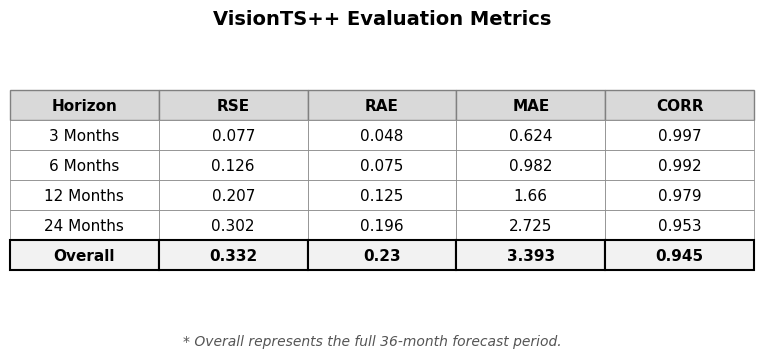

Saved: Vision_Eval_Table.png (and archived to archive/)


In [12]:
import numpy as np
import pandas as pd

# Combine the multi-model benchmark forecasts into the full-width prediction arrays.
RESULTS_DIR = os.path.join('Results', 'v2_2_full')
preds = np.load(os.path.join(RESULTS_DIR, 'visionpp_predictions.npy'))
trues = np.load(os.path.join(RESULTS_DIR, 'visionpp_ground_truth.npy'))

# keep a pure zero-shot backup next to the canonical arrays
np.save(os.path.join(RESULTS_DIR, 'visionpp_predictions_zeroshot.npy'), preds)

full_names = [str(n) for n in np.load(
    os.path.join('..', 'Processed_Data', 'visionpp', 'v2_2_full', 'feature_names.npy'),
    allow_pickle=True)]
with open(os.path.join('Preprocessing', 'v2_1_selected_features_159.txt')) as f:
    bench_names = [l.strip() for l in f if l.strip()]
bench = np.array([full_names.index(n) for n in bench_names])

mm_bench = np.load(os.path.join(MULTI_MODEL_DIR, 'test_pred_multi_model.npy'))
preds_mm = preds.copy()
preds_mm[:, :, bench] = mm_bench
np.save(os.path.join(RESULTS_DIR, 'visionpp_predictions.npy'), preds_mm)
print(f'Multi-model combined forecast saved: {len(bench)} benchmark columns reassigned, '
      f'{len(full_names) - len(bench)} columns unchanged zero-shot.')

# Recompute the evaluation CSV from the multi-model arrays (mirrors Evaluate_VisionPP).
rows = []
for h, hname in [(3, '3 Months'), (6, '6 Months'), (12, '12 Months'),
                 (24, '24 Months'), (36, 'Overall')]:
    p, t = preds_mm[:, :h, :].ravel(), trues[:, :h, :].ravel()
    mae = float(np.mean(np.abs(p - t)))
    rows.append({'Horizon': hname,
                 'RSE': float(np.sqrt(np.mean((p - t) ** 2) / (np.var(t) + 1e-7))),
                 'RAE': mae / (float(np.mean(np.abs(t - t.mean()))) + 1e-7),
                 'MAE': mae,
                 'CORR': float(np.corrcoef(p, t)[0, 1])})
pd.DataFrame(rows).to_csv(os.path.join(RESULTS_DIR, 'visionpp_evaluation_results.csv'),
                          index=False)
print('Evaluation CSV recomputed from the multi-model forecasts.')

print("\n--- PUBLICATION PREVIEW: Evaluation Metrics (multi-model) ---")
visualise_evaluation_metrics(dataset=DATASET)

In [ ]:
# Reload vis_data so all visualisations below use the MULTI-MODEL forecasts
vis_data = load_visualisation_data(dataset=DATASET)
# Plot-level smoothing (visualisation only. metrics stay unsmoothed)
vis_data = smooth_vis_data(vis_data)

if vis_data:
  print("Multi-model data Loaded Successfully.")
else:
  print("Failed to load data.")

--- Loading Visualisation Data ---
Loading Full History from: Data_Preparation/Cyber_Trend_Forecasting_All_v2_2_sarimax.csv
Multi-model data Loaded Successfully.



--- FORECAST ACCURACY: Ground Truth vs Prediction ---


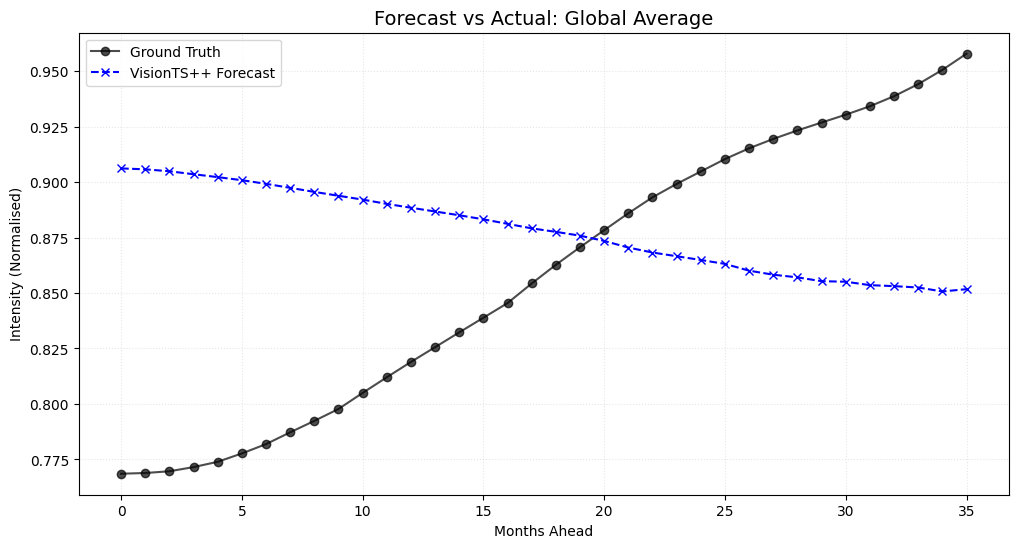

Saved: Global_Forecast_Accuracy.png (and archived to archive/)

--- GAP ANALYSIS: Threat vs Mitigation ---


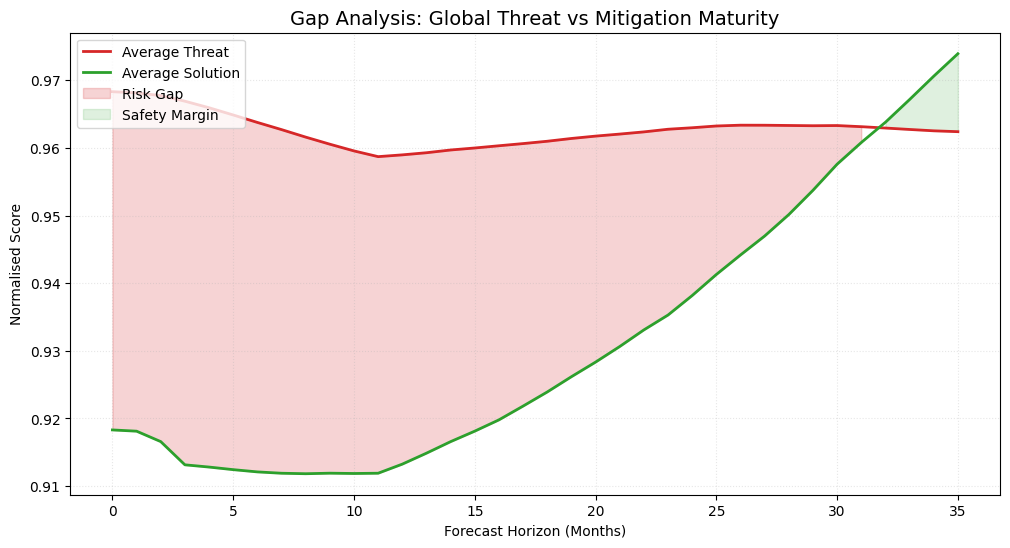

Saved: Global_Gap_Analysis.png (and archived to archive/)


In [14]:
if vis_data:
    perform_broad_analysis(vis_data)


--- Figure 3: Forecast Accuracy (Ground Truth vs Prediction) ---


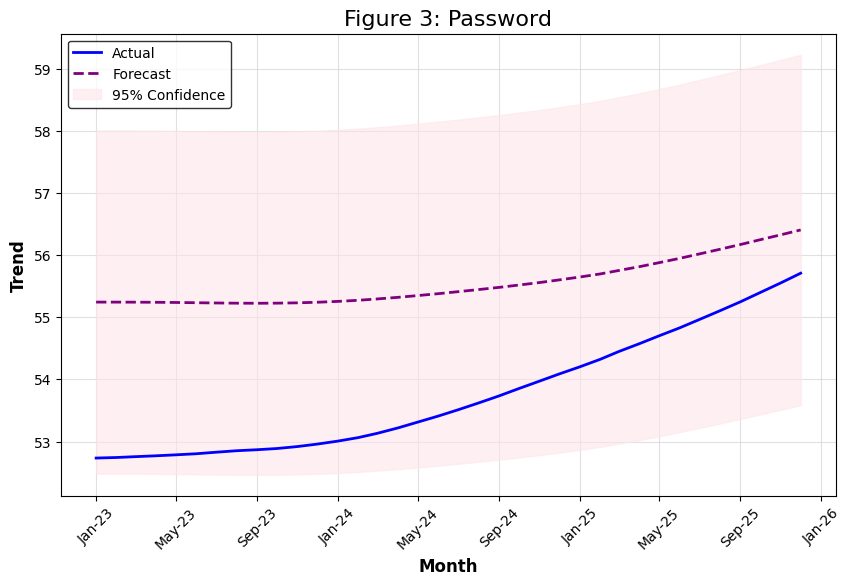

Saved: Fig3_Password.png (and archived to archive/)


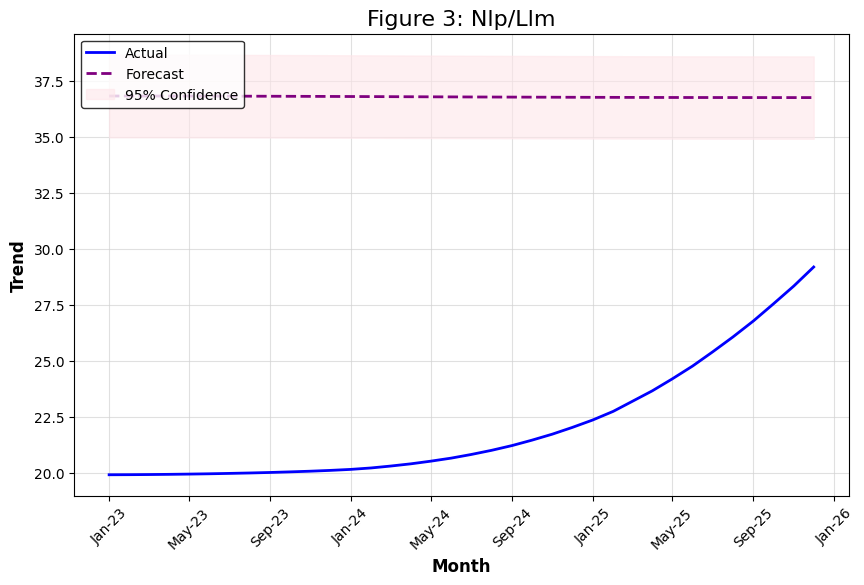

Saved: Fig3_Nlp_Llm.png (and archived to archive/)


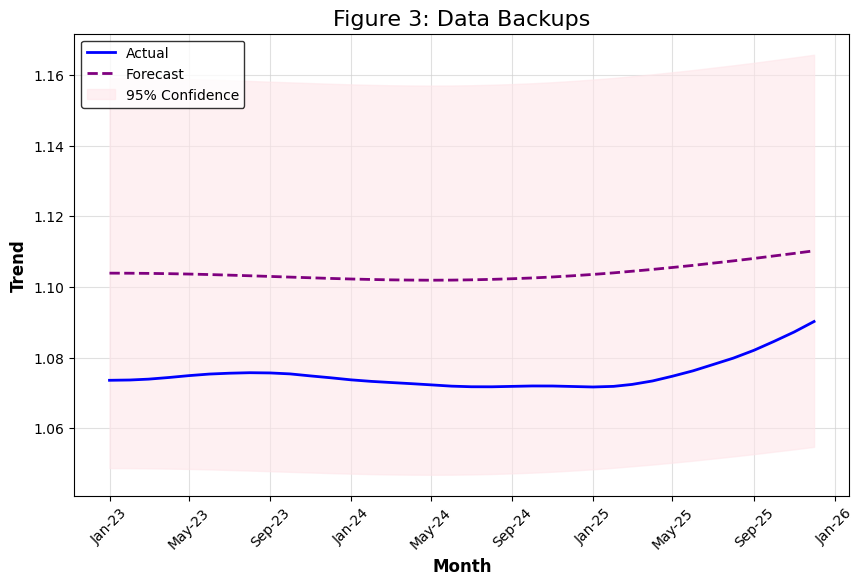

Saved: Fig3_Data_Backups.png (and archived to archive/)


In [15]:
if vis_data:
    plot_validation_forecasts(vis_data)


--- GAP TABLES: Widening & Narrowing ---


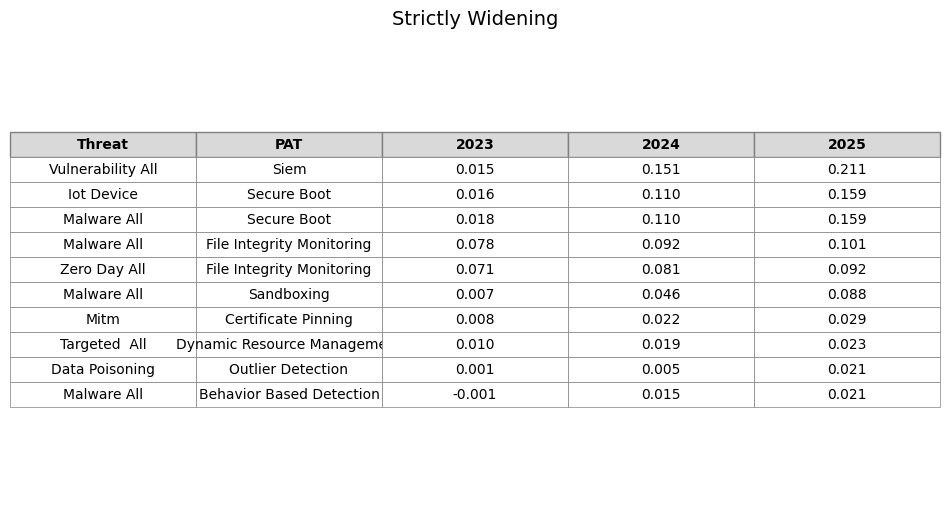

Saved: Strictly_Widening.png (and archived to archive/)

--- Table 5a: Strictly Widening Gaps (Top 5) ---
           Threat                       PAT  2023  2024  2025
Vulnerability All                      Siem 0.015 0.151 0.211
       Iot Device               Secure Boot 0.016 0.110 0.159
      Malware All               Secure Boot 0.018 0.110 0.159
      Malware All File Integrity Monitoring 0.078 0.092 0.101
     Zero Day All File Integrity Monitoring 0.071 0.081 0.092


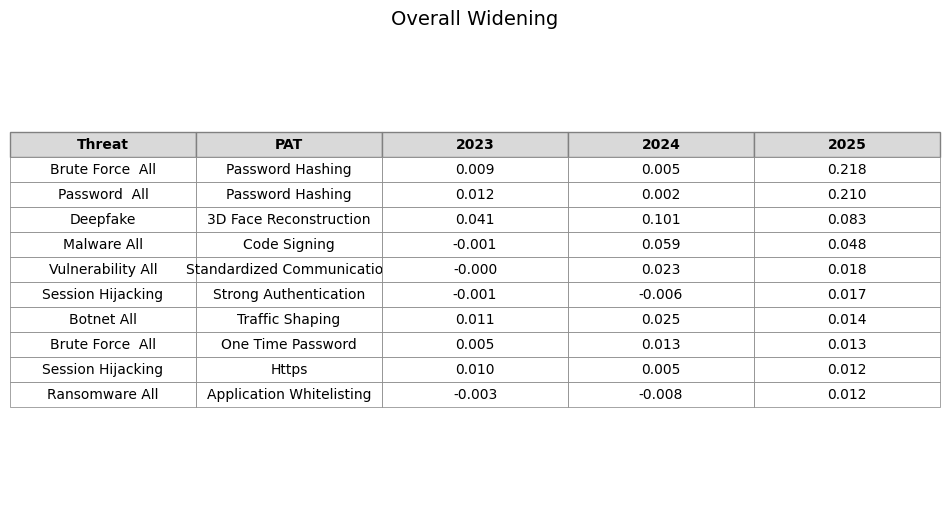

Saved: Overall_Widening.png (and archived to archive/)

--- Table 5b: Overall Widening Gaps (Top 5) ---
           Threat                        PAT   2023  2024  2025
 Brute Force  All           Password Hashing  0.009 0.005 0.218
    Password  All           Password Hashing  0.012 0.002 0.210
         Deepfake     3D Face Reconstruction  0.041 0.101 0.083
      Malware All               Code Signing -0.001 0.059 0.048
Vulnerability All Standardized Communication -0.000 0.023 0.018


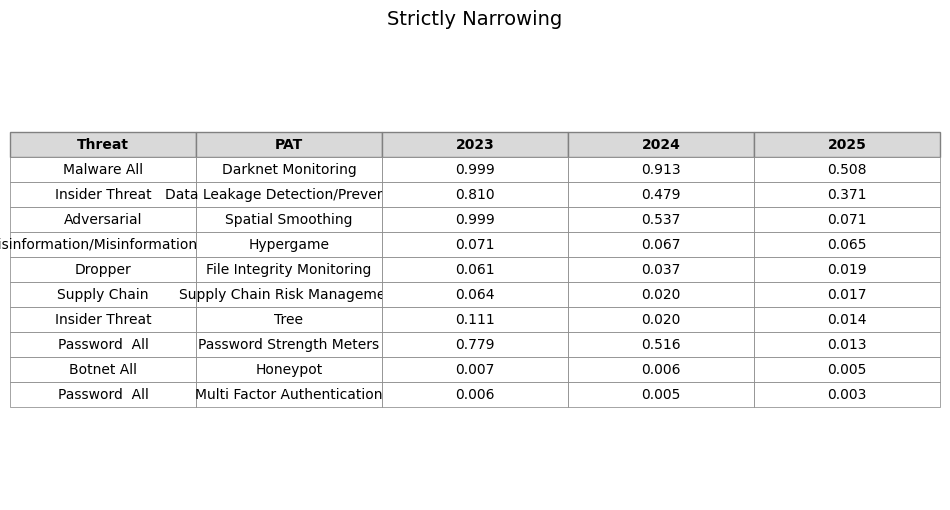

Saved: Strictly_Narrowing.png (and archived to archive/)

--- Table 6a: Strictly Narrowing Gaps (Top 5) ---
                           Threat                               PAT  2023  2024  2025
                      Malware All                Darknet Monitoring 0.999 0.913 0.508
                   Insider Threat Data Leakage Detection/Prevention 0.810 0.479 0.371
                      Adversarial                 Spatial Smoothing 0.999 0.537 0.071
Disinformation/Misinformation All                         Hypergame 0.071 0.067 0.065
                          Dropper         File Integrity Monitoring 0.061 0.037 0.019


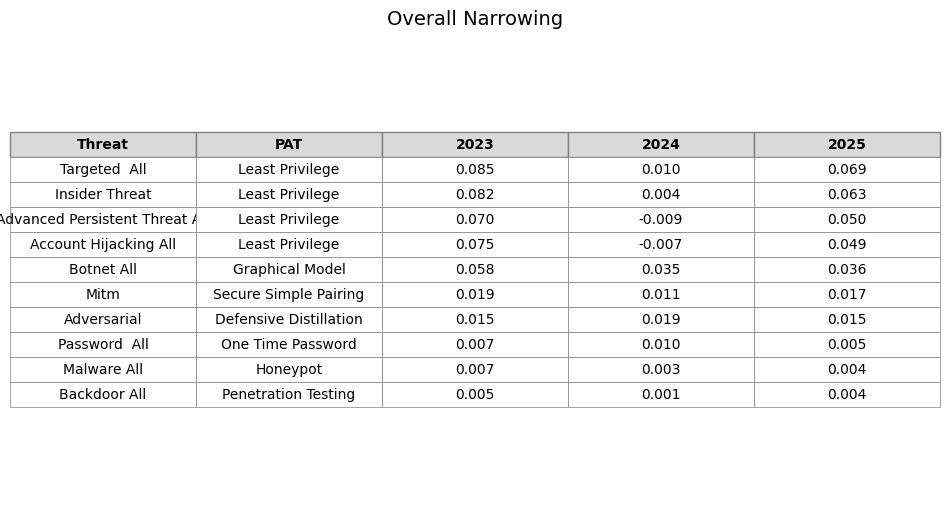

Saved: Overall_Narrowing.png (and archived to archive/)

--- Table 6b: Overall Narrowing Gaps (Top 5) ---
                        Threat             PAT  2023   2024  2025
                 Targeted  All Least Privilege 0.085  0.010 0.069
                Insider Threat Least Privilege 0.082  0.004 0.063
Advanced Persistent Threat All Least Privilege 0.070 -0.009 0.050
         Account Hijacking All Least Privilege 0.075 -0.007 0.049
                    Botnet All Graphical Model 0.058  0.035 0.036


In [16]:
if vis_data:
  generate_gap_analysis_tables(vis_data)


--- PAPER FIG 4: Continuous Trends ---


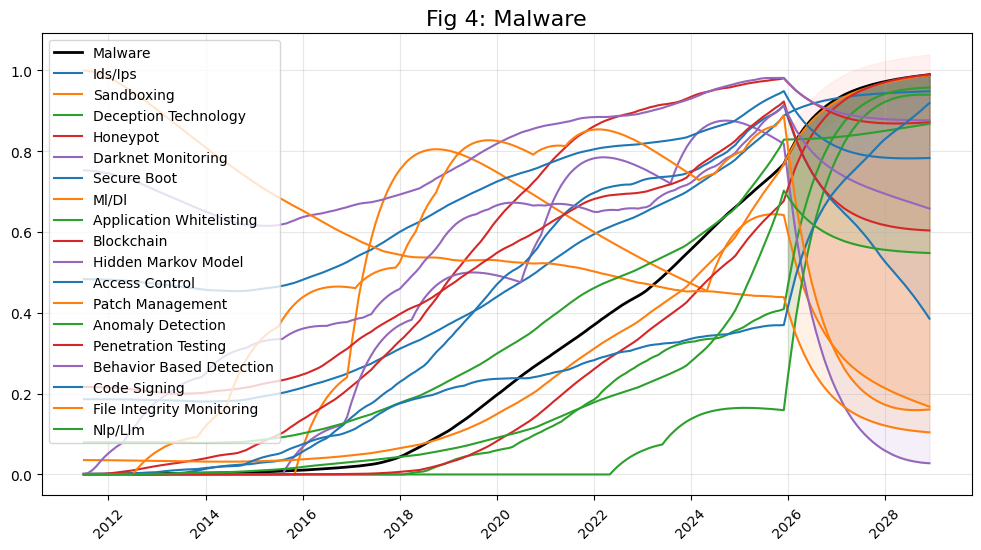

Saved: Fig4_Malware.png (and archived to archive/)


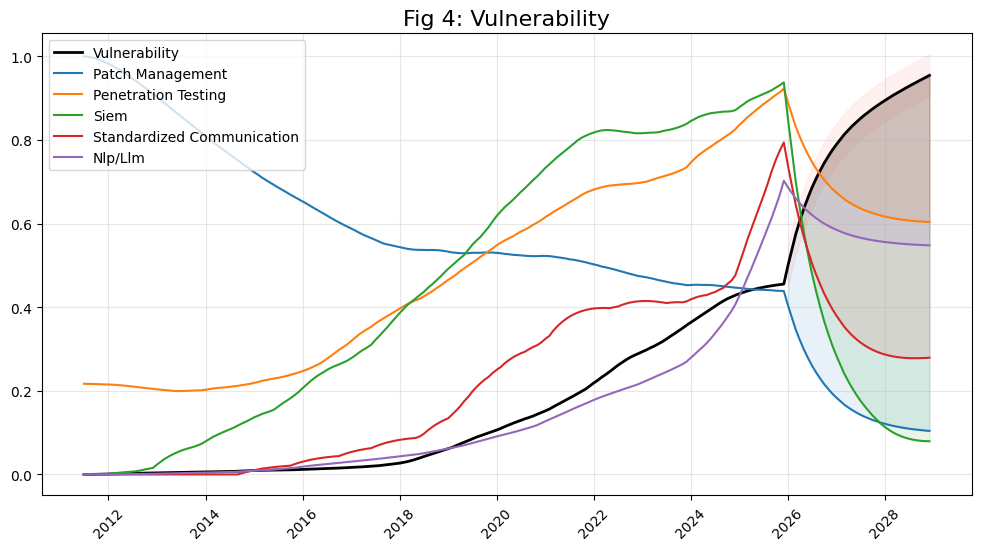

Saved: Fig4_Vulnerability.png (and archived to archive/)


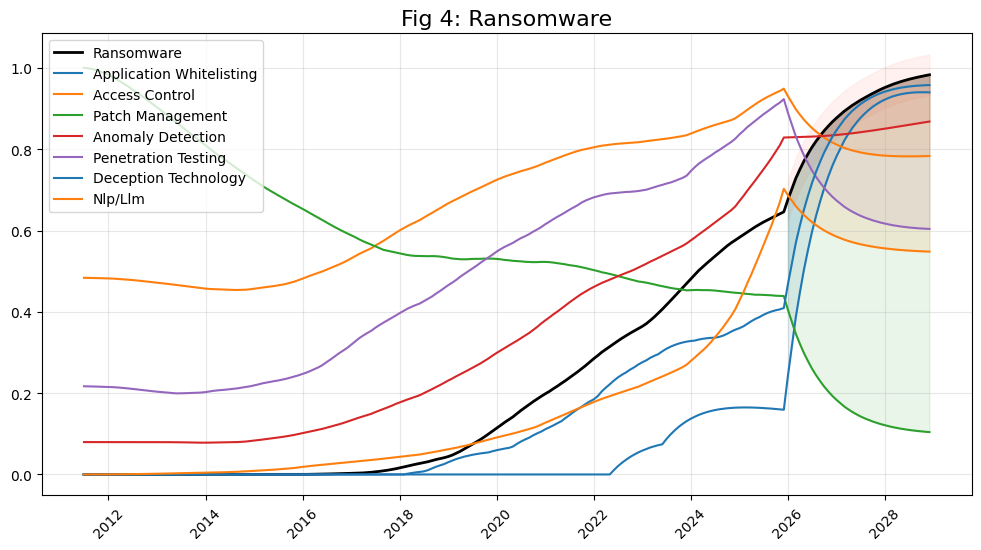

Saved: Fig4_Ransomware.png (and archived to archive/)


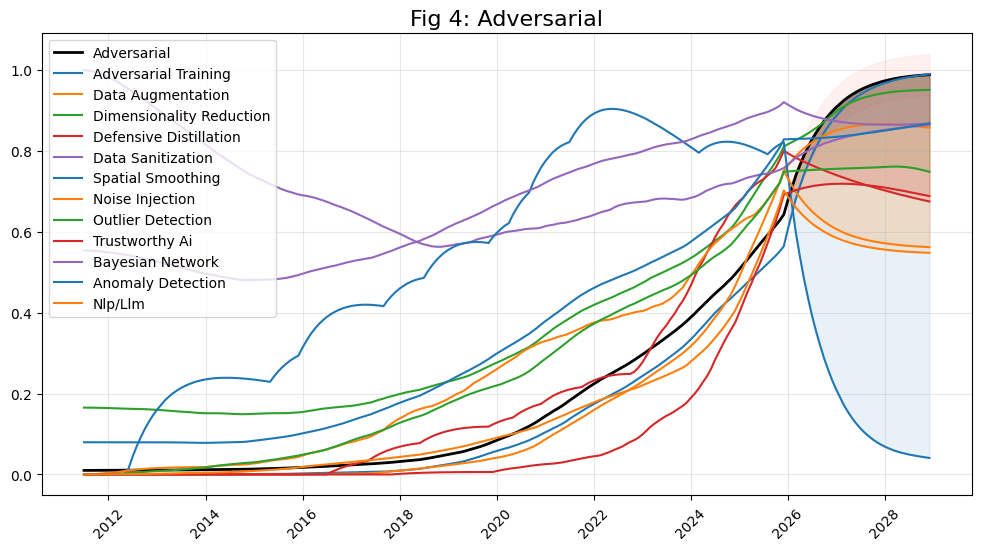

Saved: Fig4_Adversarial.png (and archived to archive/)


In [17]:
if vis_data:
    plot_continuous_trends(vis_data)